# Credit Risk Modelling — Give Me Some Credit (Kaggle)

**Dataset:** 150,000 borrowers, target: SeriousDlqin2yrs (6.7% default rate)  
**Objective:** Compare ML models and build an industry-standard WoE credit scorecard  
**Models:** Logistic Regression · Spline LR · LDA · QDA · KNN · Random Forest · XGBoost · WoE Scorecard

## 1. Setup — Imports and Data Loading

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scorecardpy as sc
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ── Load and clean data ────────────────────────────────────────────
df = pd.read_csv(r'C:\Users\Srinivasa S Vemuri\Downloads\archive\cs-training.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Shape: {df.shape}')
print(f'Default rate: {df["SeriousDlqin2yrs"].mean():.4f} ({df["SeriousDlqin2yrs"].mean()*100:.1f}%)')
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (150000, 11)
Default rate: 0.0668 (6.7%)

Missing values:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


## 2. Exploratory Data Analysis

MonthlyIncome: Skewness=127.12  Mean-Median=1018.5
NumberOfDependents: Skewness=1.63  Mean-Median=0.7


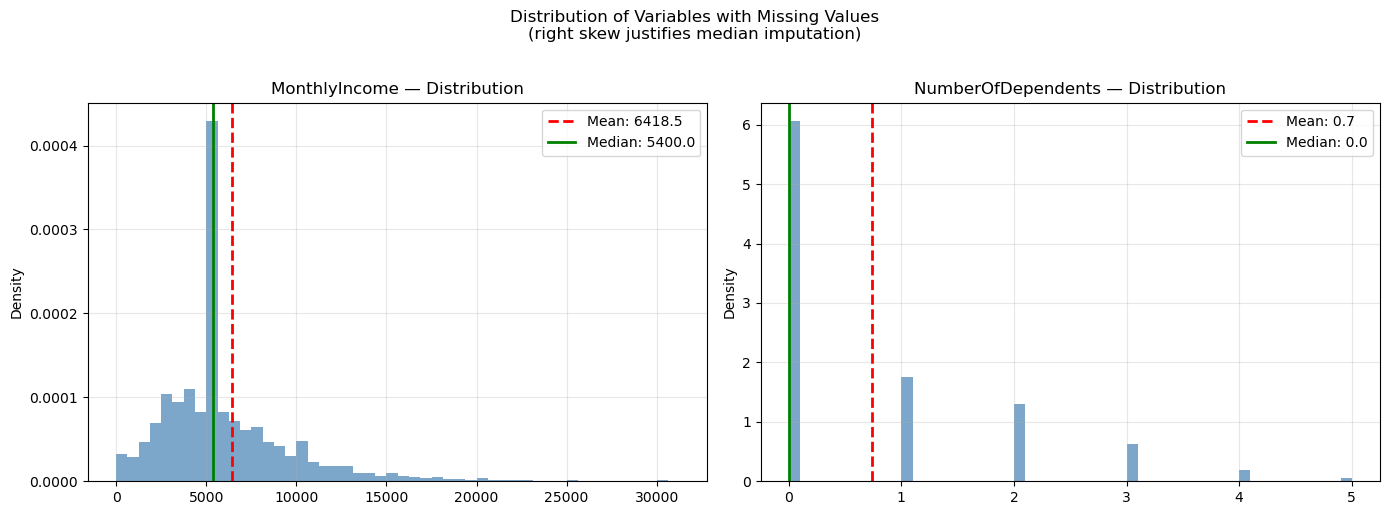

In [3]:
# ── Impute missing values (median — justified by right skew) ──────
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# ── Distribution plots: justify median imputation ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ['MonthlyIncome', 'NumberOfDependents']):
    data      = df[feature].dropna()
    mu        = data.mean()
    median    = data.median()
    clipped   = data[data <= data.quantile(0.995)]

    ax.hist(clipped, bins=50, density=True, color='steelblue', alpha=0.7)
    ax.axvline(mu,     color='red',   lw=2, ls='--', label=f'Mean: {mu:.1f}')
    ax.axvline(median, color='green', lw=2, ls='-',  label=f'Median: {median:.1f}')
    ax.set_title(f'{feature} — Distribution')
    ax.set_ylabel('Density'); ax.legend(); ax.grid(True, alpha=0.3)
    print(f'{feature}: Skewness={stats.skew(data):.2f}  Mean-Median={mu-median:.1f}')

plt.suptitle('Distribution of Variables with Missing Values\n(right skew justifies median imputation)',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

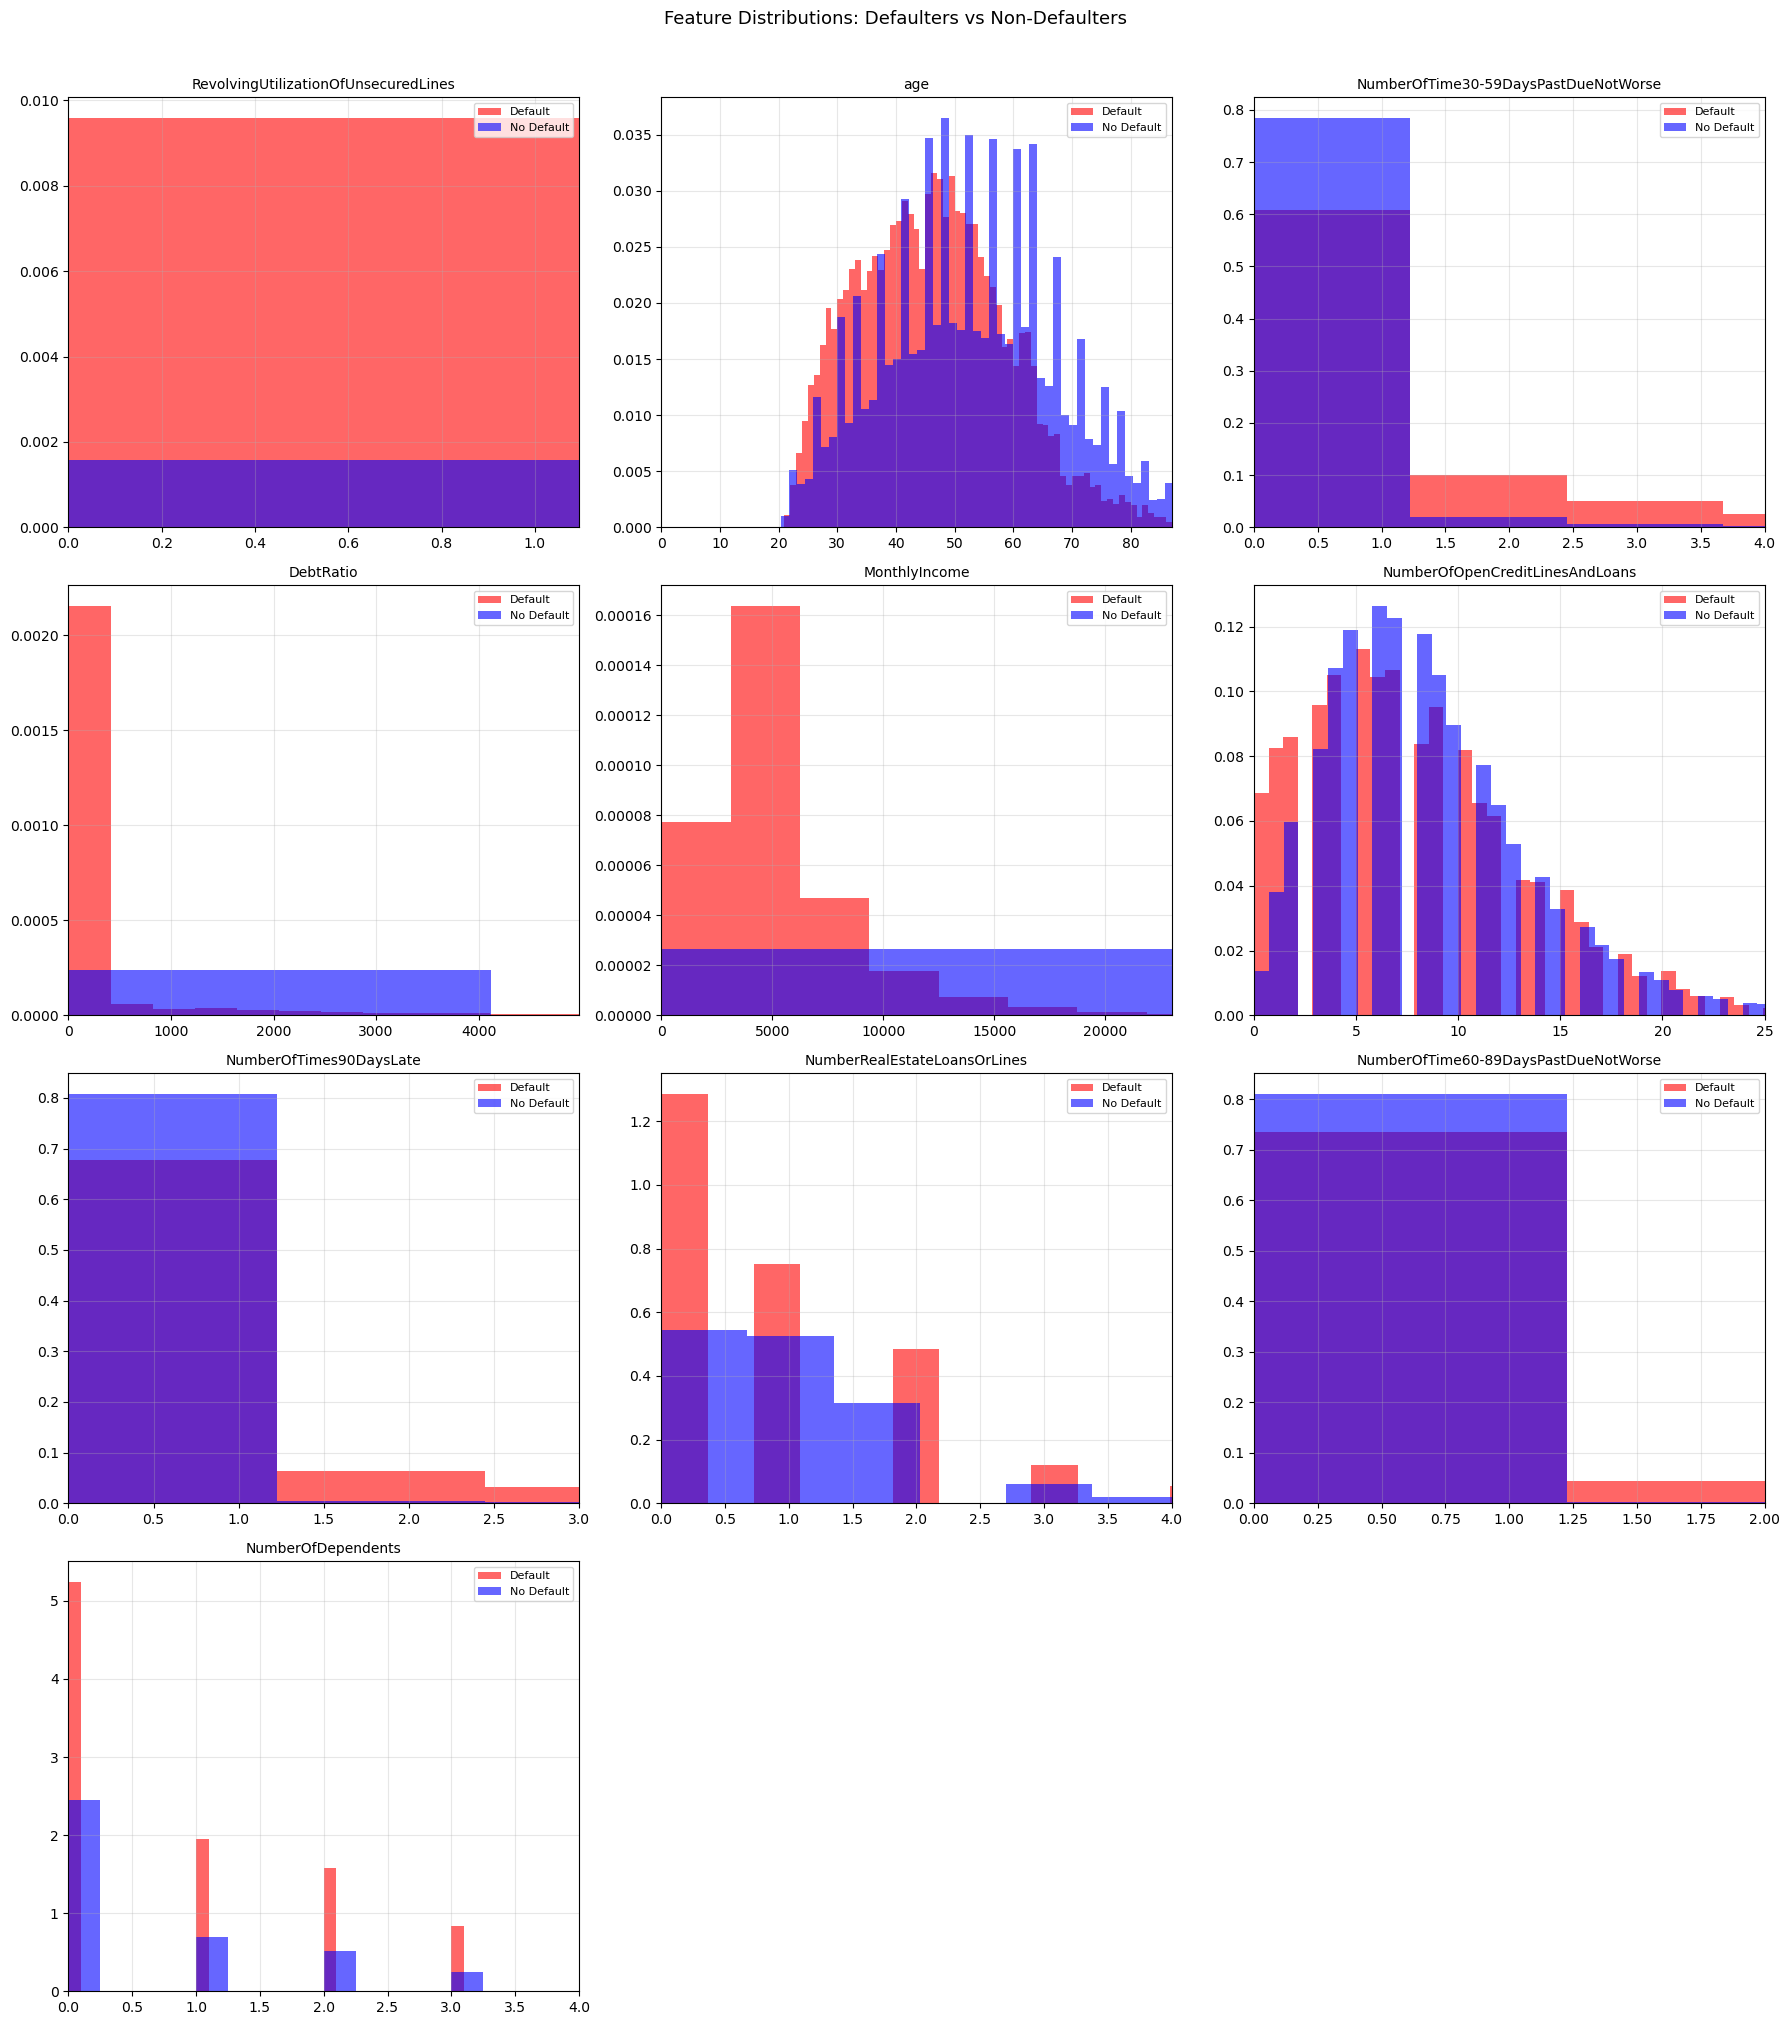

In [4]:
# ── Feature distributions by default status ───────────────────────
X_full = df.drop(columns=['SeriousDlqin2yrs'])
y_full = df['SeriousDlqin2yrs']

X_train_eda, X_test_eda, y_train_eda, y_test_eda = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

X_def   = X_train_eda[y_train_eda == 1]
X_nodef = X_train_eda[y_train_eda == 0]

features = X_full.columns.tolist()
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):
    xlim = X_train_eda[feat].quantile(0.99)
    axes[i].hist(X_def[feat],   bins=80, alpha=0.6, color='red',  density=True, label='Default')
    axes[i].hist(X_nodef[feat], bins=80, alpha=0.6, color='blue', density=True, label='No Default')
    axes[i].set_xlim(X_train_eda[feat].min(), xlim)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.3)

for j in range(len(features), len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature Distributions: Defaulters vs Non-Defaulters', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

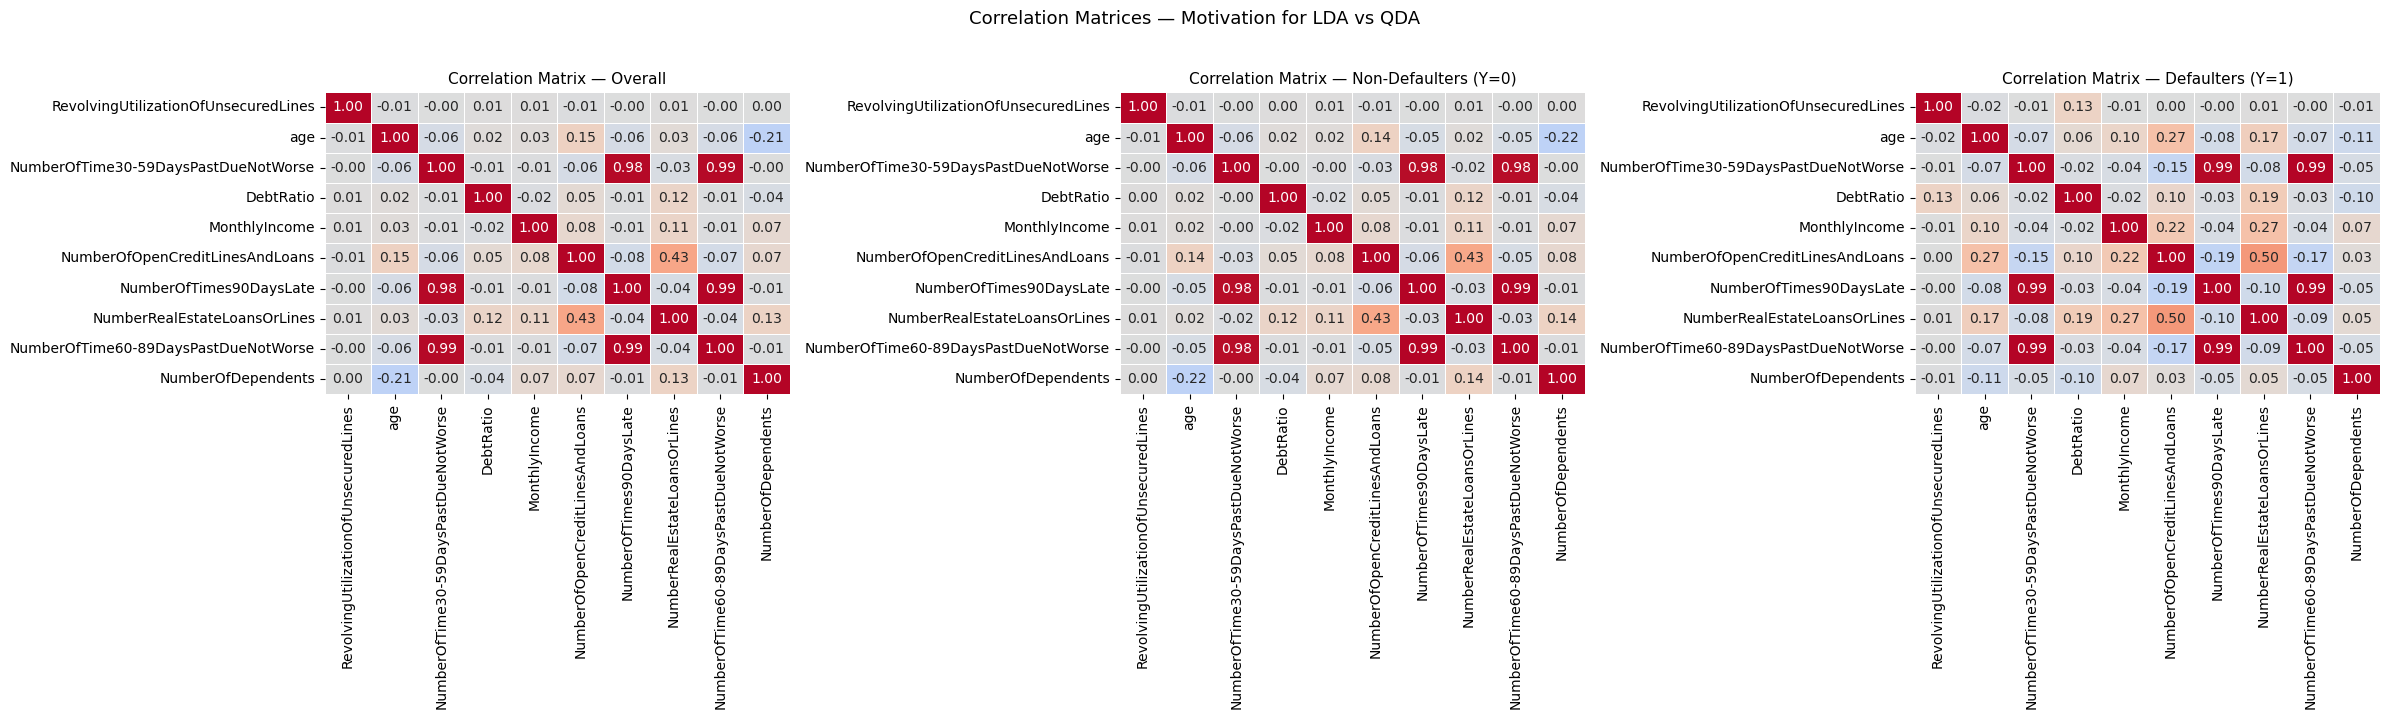

In [5]:
# ── Correlation matrices: overall + by class ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, data, title in [
    (axes[0], X_train_eda,              'Overall'),
    (axes[1], X_nodef,                  'Non-Defaulters (Y=0)'),
    (axes[2], X_def,                    'Defaulters (Y=1)'),
]:
    sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'Correlation Matrix — {title}', fontsize=11)

plt.suptitle('Correlation Matrices — Motivation for LDA vs QDA', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Data Split and Shared Setup for ML Models

In [6]:
# ── Features used across all ML models ────────────────────────────
raw_cols = [
    'MonthlyIncome', 'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines',
    'age', 'NumberOfOpenCreditLinesAndLoans'
]

X = df[raw_cols].copy()
y = df['SeriousDlqin2yrs']

# ── Three-way split: train (64%) | val (16%) | test (20%) ─────────
X_trainval, X_test_raw, y_trainval, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

scale_pos = (y_train_raw == 0).sum() / (y_train_raw == 1).sum()
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv5  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)

print(f'Train:      {X_train_raw.shape[0]:>7} ({X_train_raw.shape[0]/len(X):.0%})')
print(f'Validation: {X_val.shape[0]:>7} ({X_val.shape[0]/len(X):.0%})')
print(f'Test:       {X_test_raw.shape[0]:>7} ({X_test_raw.shape[0]/len(X):.0%})')
print(f'Default rate — Train: {y_train_raw.mean():.4f}  Val: {y_val.mean():.4f}  Test: {y_test_raw.mean():.4f}')

Train:        96000 (64%)
Validation:   24000 (16%)
Test:         30000 (20%)
Default rate — Train: 0.0668  Val: 0.0668  Test: 0.0668


## 4. Baseline Models

Logistic Regression establishes the linear baseline. LDA and QDA test discriminant analysis assumptions. KNN provides a non-parametric local comparison.

LR     | Train: 0.6905 | Test: 0.7123 | Gap: -0.0218
LDA    | Train: 0.6870 | Test: 0.7065 | Gap: -0.0194
QDA    | Train: 0.7911 | Test: 0.7955 | Gap: -0.0044
KNN(k=220) | Train: 0.8204 | Test: 0.8056 | Gap: 0.0148


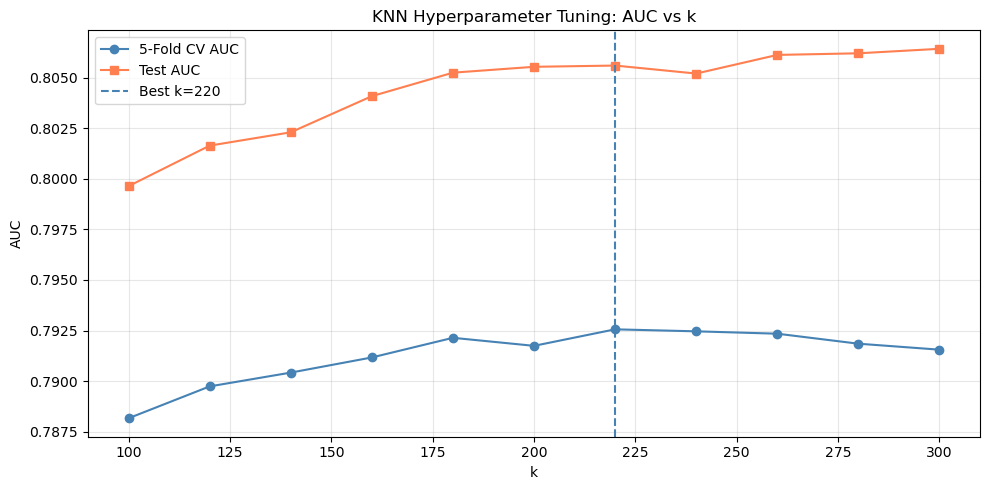

In [ ]:
# ── Logistic Regression ───────────────────────────────────────────
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_raw, y_train_raw)
auc_lr_train = roc_auc_score(y_train_raw, lr.predict_proba(X_train_raw)[:,1])
auc_lr_test  = roc_auc_score(y_test_raw,  lr.predict_proba(X_test_raw)[:,1])
print(f'LR     | Train: {auc_lr_train:.4f} | Test: {auc_lr_test:.4f} | Gap: {auc_lr_train-auc_lr_test:.4f}')

# ── LDA ───────────────────────────────────────────────────────────
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_raw, y_train_raw)
auc_lda_train = roc_auc_score(y_train_raw, lda.predict_proba(X_train_raw)[:,1])
auc_lda_test  = roc_auc_score(y_test_raw,  lda.predict_proba(X_test_raw)[:,1])
print(f'LDA    | Train: {auc_lda_train:.4f} | Test: {auc_lda_test:.4f} | Gap: {auc_lda_train-auc_lda_test:.4f}')

# ── QDA ───────────────────────────────────────────────────────────
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_raw, y_train_raw)
auc_qda_train = roc_auc_score(y_train_raw, qda.predict_proba(X_train_raw)[:,1])
auc_qda_test  = roc_auc_score(y_test_raw,  qda.predict_proba(X_test_raw)[:,1])
print(f'QDA    | Train: {auc_qda_train:.4f} | Test: {auc_qda_test:.4f} | Gap: {auc_qda_train-auc_qda_test:.4f}')

# ── KNN (hyperparameter tuning: k = 100 to 300) ───────────────────
k_range   = range(100, 301, 20)
cv_aucs   = []
test_aucs = []

for k in k_range:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k, n_jobs=-1))])
    cv_aucs.append(cross_val_score(pipe, X_train_raw, y_train_raw,
                                    cv=cv5, scoring='roc_auc', n_jobs=-1).mean())
    pipe.fit(X_train_raw, y_train_raw)
    test_aucs.append(roc_auc_score(y_test_raw, pipe.predict_proba(X_test_raw)[:,1]))

best_k = list(k_range)[np.argmax(cv_aucs)]
knn_best = Pipeline([('scaler', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1))])
knn_best.fit(X_train_raw, y_train_raw)
auc_knn_train = roc_auc_score(y_train_raw, knn_best.predict_proba(X_train_raw)[:,1])
auc_knn_test  = roc_auc_score(y_test_raw,  knn_best.predict_proba(X_test_raw)[:,1])
print(f'KNN(k={best_k}) | Train: {auc_knn_train:.4f} | Test: {auc_knn_test:.4f} | Gap: {auc_knn_train-auc_knn_test:.4f}')

# ── KNN tuning plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), cv_aucs,   marker='o', color='steelblue', label='5-Fold CV AUC')
ax.plot(list(k_range), test_aucs, marker='s', color='coral',     label='Test AUC')
ax.axvline(best_k, color='steelblue', ls='--', label=f'Best k={best_k}')
ax.set_xlabel('k'); ax.set_ylabel('AUC')
ax.set_title('KNN Hyperparameter Tuning: AUC vs k')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 5. Spline Logistic Regression

Logistic regression assumes a linear relationship between each predictor and log-odds. Splines relax this — the large AUC improvement directly demonstrates non-linearity in the data.

n_knots=2: 0.7404 ± 0.0068
n_knots=3: 0.7975 ± 0.0065
n_knots=4: 0.8065 ± 0.0068
n_knots=5: 0.8126 ± 0.0061
n_knots=6: 0.8149 ± 0.0058
n_knots=7: 0.8168 ± 0.0058
n_knots=8: 0.8187 ± 0.0057
n_knots=9: 0.8196 ± 0.0058
n_knots=10: 0.8210 ± 0.0055
n_knots=11: 0.8217 ± 0.0054
n_knots=12: 0.8221 ± 0.0054
n_knots=13: 0.8221 ± 0.0052
n_knots=14: 0.8224 ± 0.0053
n_knots=15: 0.8227 ± 0.0053
n_knots=16: 0.8231 ± 0.0052
n_knots=17: 0.8233 ± 0.0056
n_knots=18: 0.8241 ± 0.0051
n_knots=19: 0.8239 ± 0.0051
n_knots=20: 0.8250 ± 0.0054
n_knots=21: 0.8251 ± 0.0056
n_knots=22: 0.8255 ± 0.0053
n_knots=23: 0.8255 ± 0.0053
n_knots=24: 0.8256 ± 0.0055
n_knots=25: 0.8258 ± 0.0056
n_knots=26: 0.8256 ± 0.0054
n_knots=27: 0.8258 ± 0.0054
n_knots=28: 0.8255 ± 0.0053
n_knots=29: 0.8255 ± 0.0052


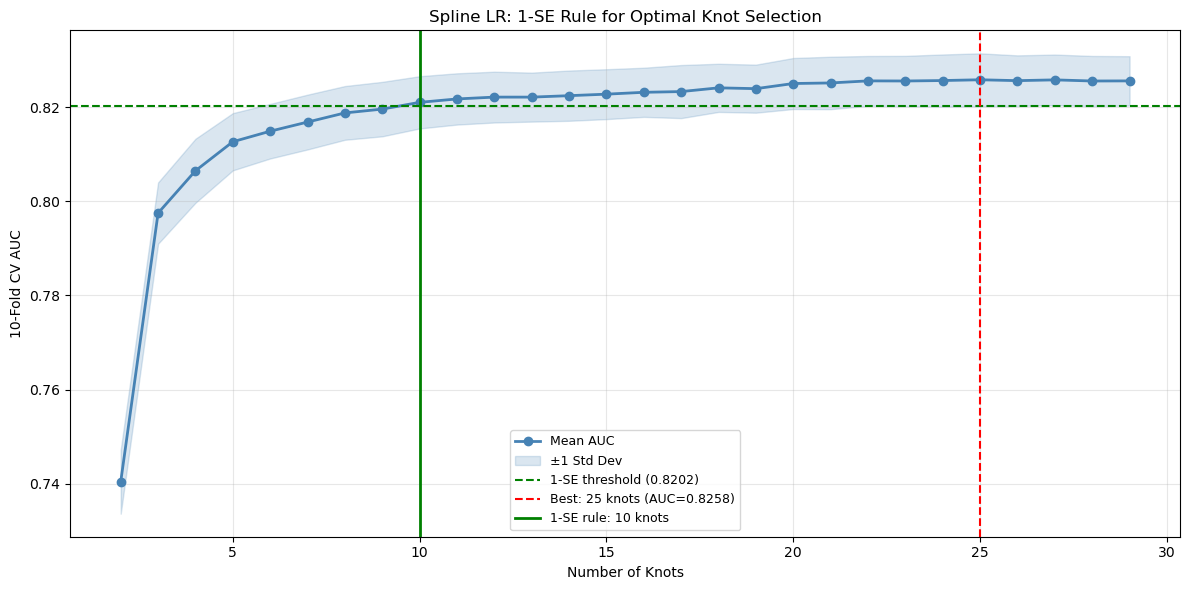

Best knots: 25  |  1-SE knots: 10
1-SE AUC sacrifice: 0.0048


In [ ]:
# ── Knot selection: AUC vs number of knots ────────────────────────
knots_range = range(2, 30)
mean_aucs   = []
std_aucs    = []

for n_knots in knots_range:
    pipe = Pipeline([('spline', SplineTransformer(n_knots=n_knots, degree=3)),
                     ('lr',     LogisticRegression(max_iter=1000))])
    scores = cross_val_score(pipe, X, y, cv=cv10, scoring='roc_auc', n_jobs=-1)
    mean_aucs.append(scores.mean())
    std_aucs.append(scores.std())
    print(f'n_knots={n_knots}: {scores.mean():.4f} ± {scores.std():.4f}')

mean_aucs = np.array(mean_aucs)
std_aucs  = np.array(std_aucs)
best_knots = list(knots_range)[np.argmax(mean_aucs)]

# ── 1-SE Rule ─────────────────────────────────────────────────────
threshold    = max(mean_aucs) - std_aucs[np.argmax(mean_aucs)]
ose_knots    = next(k for i,k in enumerate(knots_range) if mean_aucs[i] >= threshold)


# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(knots_range, mean_aucs, marker='o', color='steelblue', lw=2, label='Mean AUC')
ax.fill_between(knots_range, mean_aucs-std_aucs, mean_aucs+std_aucs,
                alpha=0.2, color='steelblue', label='±1 Std Dev')
ax.axhline(threshold, color='green', ls='--', label=f'1-SE threshold ({threshold:.4f})')
ax.axvline(best_knots, color='red',   ls='--', label=f'Best: {best_knots} knots (AUC={max(mean_aucs):.4f})')
ax.axvline(ose_knots,  color='green', ls='-',  lw=2, label=f'1-SE rule: {ose_knots} knots')
ax.set_xlabel('Number of Knots'); ax.set_ylabel('10-Fold CV AUC')
ax.set_title('Spline LR: 1-SE Rule for Optimal Knot Selection')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f'Best knots: {best_knots}  |  1-SE knots: {ose_knots}')
print(f'1-SE AUC sacrifice: {max(mean_aucs) - mean_aucs[list(knots_range).index(ose_knots)]:.4f}')

In [11]:
spline_pipe = Pipeline([
    ('spline', SplineTransformer(n_knots=ose_knots, degree=3)),
    ('lr', LogisticRegression(max_iter=1000))
])

spline_pipe.fit(X, y)

,steps,"[('spline', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_knots,10
,degree,3
,knots,'uniform'
,extrapolation,'constant'
,include_bias,True
,order,'C'
,sparse_output,False


In [9]:
# ── Fit final spline LR with 1-SE optimal knots ───────────────────
spline_pipe = Pipeline([('spline', SplineTransformer(n_knots=ose_knots, degree=3)),
                         ('lr',    LogisticRegression(max_iter=1000))])
spline_pipe.fit(X_train_raw, y_train_raw)

auc_spline_train = roc_auc_score(y_train_raw, spline_pipe.predict_proba(X_train_raw)[:,1])
auc_spline_test  = roc_auc_score(y_test_raw,  spline_pipe.predict_proba(X_test_raw)[:,1])
print(f'Spline LR (k={ose_knots}) | Train: {auc_spline_train:.4f} | Test: {auc_spline_test:.4f}')
print(f'Improvement over plain LR: {auc_spline_test - auc_lr_test:.4f}')

# ── Stepwise selection on plain LR ────────────────────────────────
print('\n--- Forward Stepwise Selection ---')
selected_fwd, remaining = [], features[:]
fwd_results = []

# ── Forward Stepwise Selection ─────────────────────────────────────
selected_fwd = []
remaining    = raw_cols.copy()   # ← use raw_cols, not features
fwd_results  = []

while remaining:
    best_auc, best_feat = -np.inf, None
    for feat in remaining:
        s = cross_val_score(
            LogisticRegression(max_iter=1000),
            X[selected_fwd + [feat]], y,
            cv=cv10, scoring='roc_auc', n_jobs=-1
        ).mean()
        if s > best_auc:
            best_auc, best_feat = s, feat

    selected_fwd.append(best_feat)
    remaining.remove(best_feat)
    fwd_results.append({
        'Step':         len(selected_fwd),
        'Feature Added': best_feat,
        'CV AUC':       round(best_auc, 4)
    })
    print(f"Step {len(selected_fwd)}: +'{best_feat}' → AUC {best_auc:.4f}")

print(pd.DataFrame(fwd_results).to_string(index=False))

Spline LR (k=10) | Train: 0.8179 | Test: 0.8254
Improvement over plain LR: 0.1131

--- Forward Stepwise Selection ---
Step 1: +'NumberOfTime30-59DaysPastDueNotWorse' → AUC 0.6895
Step 2: +'DebtRatio' → AUC 0.6664
Step 3: +'age' → AUC 0.6554
Step 4: +'NumberOfTime60-89DaysPastDueNotWorse' → AUC 0.6819
Step 5: +'NumberOfTimes90DaysLate' → AUC 0.6932
Step 6: +'MonthlyIncome' → AUC 0.6958
Step 7: +'RevolvingUtilizationOfUnsecuredLines' → AUC 0.6958
Step 8: +'NumberOfOpenCreditLinesAndLoans' → AUC 0.6958
 Step                        Feature Added  CV AUC
    1 NumberOfTime30-59DaysPastDueNotWorse  0.6895
    2                            DebtRatio  0.6664
    3                                  age  0.6554
    4 NumberOfTime60-89DaysPastDueNotWorse  0.6819
    5              NumberOfTimes90DaysLate  0.6932
    6                        MonthlyIncome  0.6958
    7 RevolvingUtilizationOfUnsecuredLines  0.6958
    8      NumberOfOpenCreditLinesAndLoans  0.6958


## 6. Ensemble Methods — Random Forest and XGBoost

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 50}
Best CV AUC:    0.8615


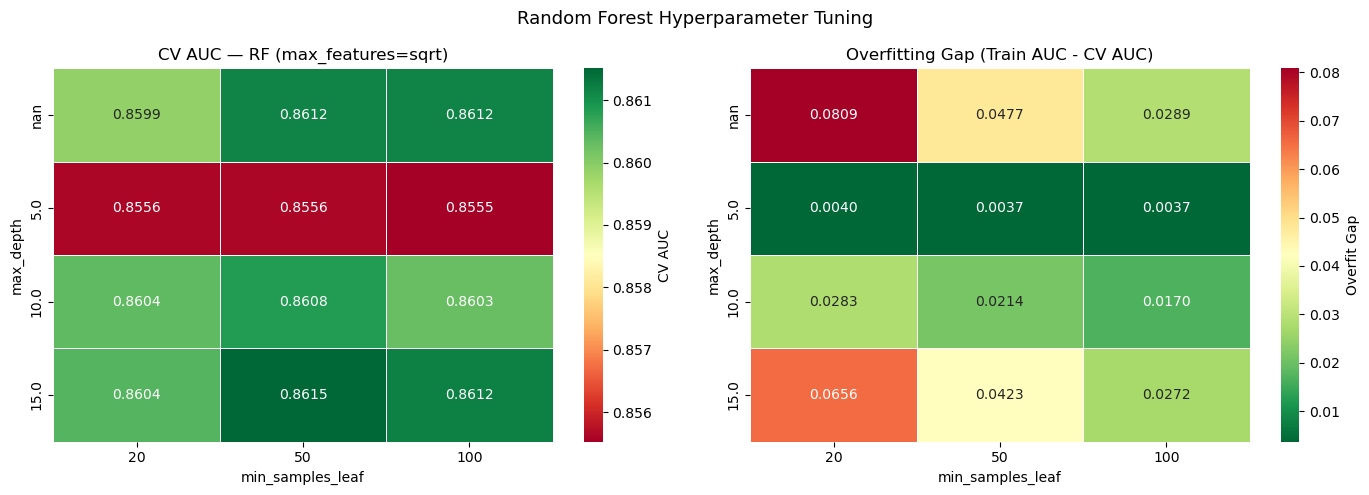

RF     | Train: 0.9014 | Test: 0.8677


In [13]:
# ── Random Forest: Grid Search hyperparameter tuning ──────────────
param_grid_rf = {
    'max_depth':        [5, 10, 15, None],
    'min_samples_leaf': [20, 50, 100],
    'max_features':     ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv5, scoring='roc_auc',
    n_jobs=-1, verbose=1, return_train_score=True
)
rf_grid.fit(X_train_raw, y_train_raw)

print(f'Best RF params: {rf_grid.best_params_}')
print(f'Best CV AUC:    {rf_grid.best_score_:.4f}')

# ── Heatmap ───────────────────────────────────────────────────────
res_rf  = pd.DataFrame(rf_grid.cv_results_)
best_mf = rf_grid.best_params_['max_features']
res_rf.columns = res_rf.columns.str.replace('param_', '')

hmap = res_rf[res_rf['max_features']==best_mf].pivot(
    index='max_depth', columns='min_samples_leaf', values='mean_test_score')
hgap = res_rf[res_rf['max_features']==best_mf].pivot(
    index='max_depth', columns='min_samples_leaf', values='mean_train_score') - hmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(hmap, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label':'CV AUC'})
axes[0].set_title(f'CV AUC — RF (max_features={best_mf})')
sns.heatmap(hgap, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'Overfit Gap'})
axes[1].set_title('Overfitting Gap (Train AUC - CV AUC)')
plt.suptitle('Random Forest Hyperparameter Tuning', fontsize=13)
plt.tight_layout(); plt.show()

# ── Final RF ──────────────────────────────────────────────────────
rf_best = RandomForestClassifier(
    max_depth=15, max_features='sqrt', min_samples_leaf=50,
    n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_best.fit(X_trainval, y_trainval)
auc_rf_train = roc_auc_score(y_trainval, rf_best.predict_proba(X_trainval)[:,1])
auc_rf_test  = roc_auc_score(y_test_raw, rf_best.predict_proba(X_test_raw)[:,1])
print(f'RF     | Train: {auc_rf_train:.4f} | Test: {auc_rf_test:.4f}')

In [14]:
# ── XGBoost: Grid Search with Early Stopping ──────────────────────
param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [3, 4, 6]
}

xgb_results = []
for lr_val in param_grid_xgb['learning_rate']:
    for depth in param_grid_xgb['max_depth']:
        xgb_tuned = XGBClassifier(
            learning_rate=lr_val, max_depth=depth,
            n_estimators=2000, early_stopping_rounds=50,
            scale_pos_weight=scale_pos, eval_metric='auc', random_state=42
        )
        xgb_tuned.fit(X_train_raw, y_train_raw,
                      eval_set=[(X_val, y_val)], verbose=False)
        xgb_results.append({
            'learning_rate': lr_val, 'max_depth': depth,
            'best_n': xgb_tuned.best_iteration,
            'val_auc': xgb_tuned.best_score
        })
        print(f'lr={lr_val}, depth={depth} → best_n={xgb_tuned.best_iteration}, val_AUC={xgb_tuned.best_score:.4f}')

xgb_res_df = pd.DataFrame(xgb_results).sort_values('val_auc', ascending=False)
print(f'\n{xgb_res_df.to_string(index=False)}')
best_xgb = xgb_res_df.iloc[0]
print(f'\nBest: lr={best_xgb.learning_rate}, depth={int(best_xgb.max_depth)}, n={int(best_xgb.best_n)}')

# ── Final XGBoost ─────────────────────────────────────────────────
xgb_final = XGBClassifier(
    learning_rate=best_xgb.learning_rate,
    max_depth=int(best_xgb.max_depth),
    n_estimators=int(best_xgb.best_n),
    scale_pos_weight=scale_pos, random_state=42
)
xgb_final.fit(X_trainval, y_trainval)
auc_xgb_train = roc_auc_score(y_trainval, xgb_final.predict_proba(X_trainval)[:,1])
auc_xgb_test  = roc_auc_score(y_test_raw, xgb_final.predict_proba(X_test_raw)[:,1])
print(f'XGB    | Train: {auc_xgb_train:.4f} | Test: {auc_xgb_test:.4f}')

lr=0.01, depth=3 → best_n=806, val_AUC=0.8628
lr=0.01, depth=4 → best_n=708, val_AUC=0.8625
lr=0.01, depth=6 → best_n=394, val_AUC=0.8614
lr=0.05, depth=3 → best_n=245, val_AUC=0.8632
lr=0.05, depth=4 → best_n=125, val_AUC=0.8623
lr=0.05, depth=6 → best_n=69, val_AUC=0.8615
lr=0.1, depth=3 → best_n=122, val_AUC=0.8635
lr=0.1, depth=4 → best_n=67, val_AUC=0.8628
lr=0.1, depth=6 → best_n=39, val_AUC=0.8614

 learning_rate  max_depth  best_n  val_auc
          0.10          3     122 0.863461
          0.05          3     245 0.863205
          0.01          3     806 0.862828
          0.10          4      67 0.862803
          0.01          4     708 0.862534
          0.05          4     125 0.862315
          0.05          6      69 0.861455
          0.10          6      39 0.861437
          0.01          6     394 0.861421

Best: lr=0.1, depth=3, n=122
XGB    | Train: 0.8689 | Test: 0.8687


## 7. WoE Credit Scorecard

Industry-standard method used by banks and rating agencies. WoE transformation linearises non-linear relationships and handles missing values natively as a separate bin.

Train: (120000, 11)  Test: (30000, 11)
[INFO] creating woe binning ...
Binning on 120000 rows and 11 columns in 00:00:21


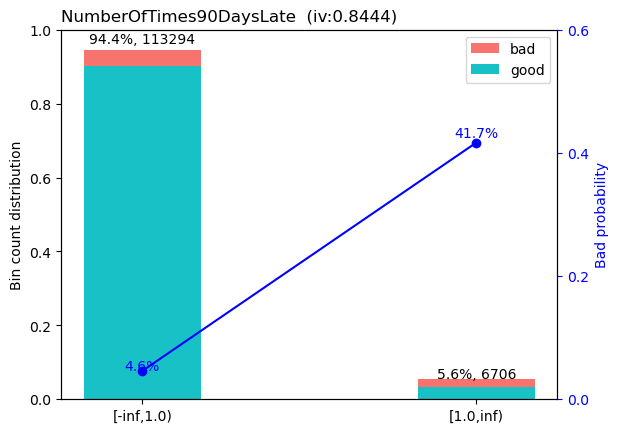

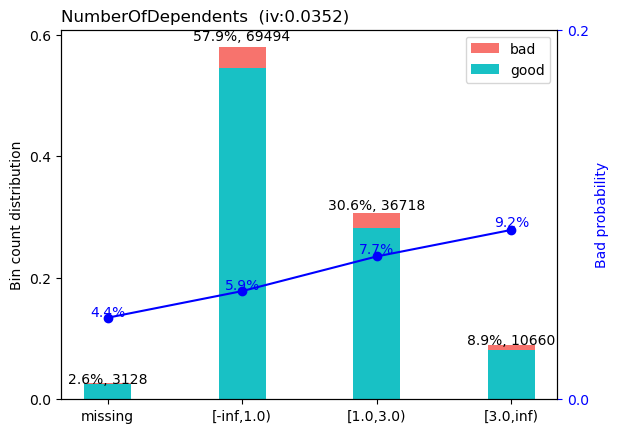

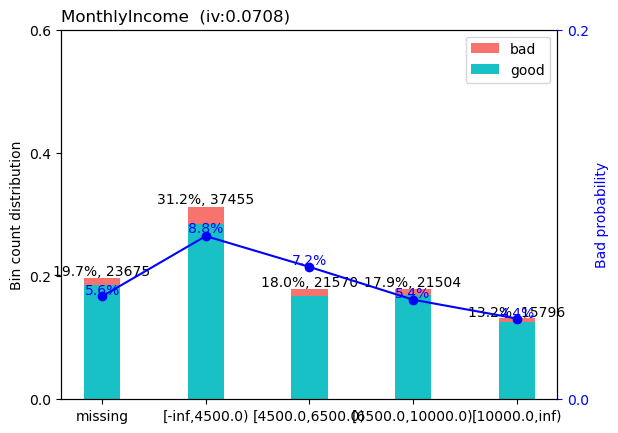

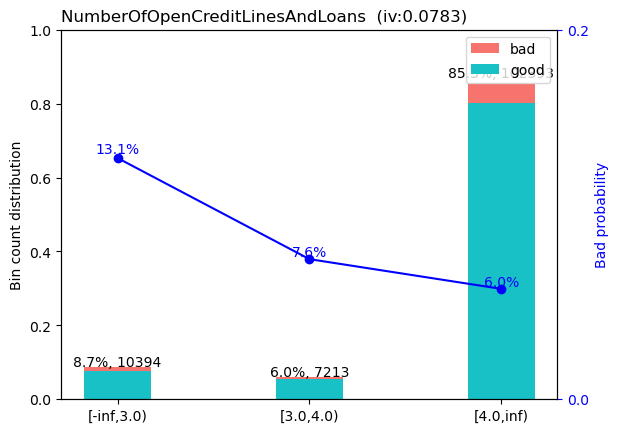

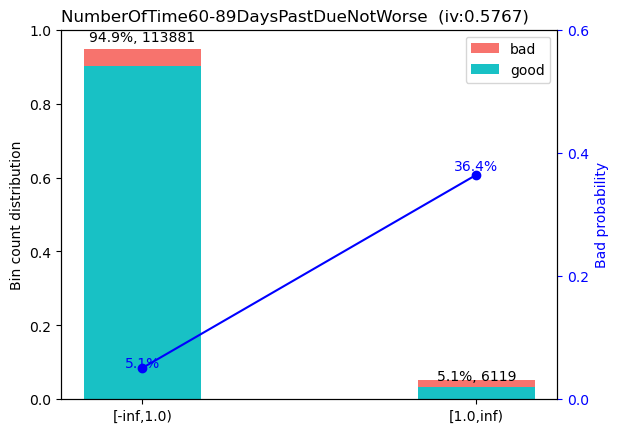

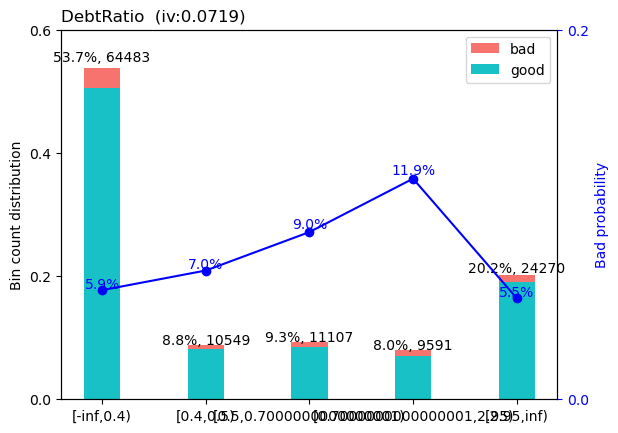

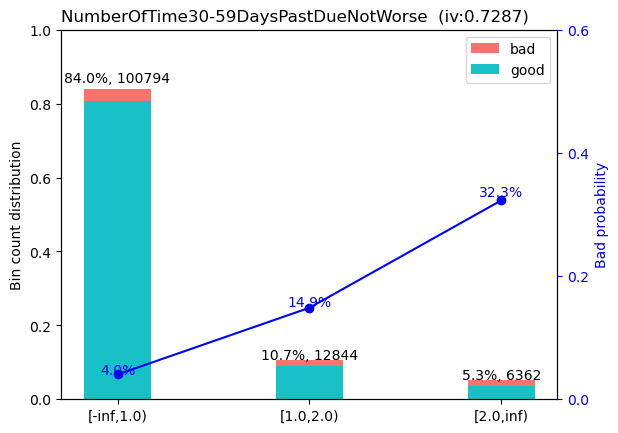

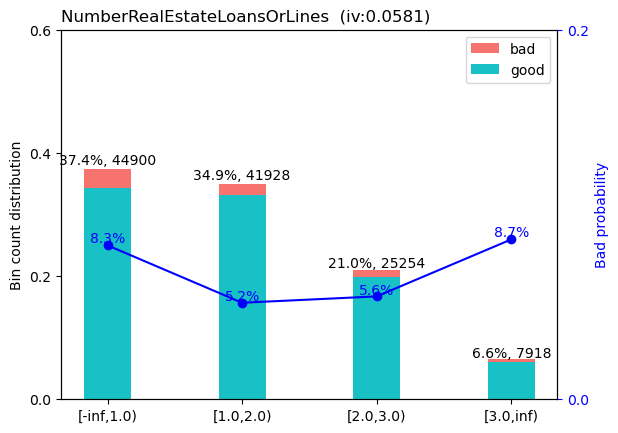

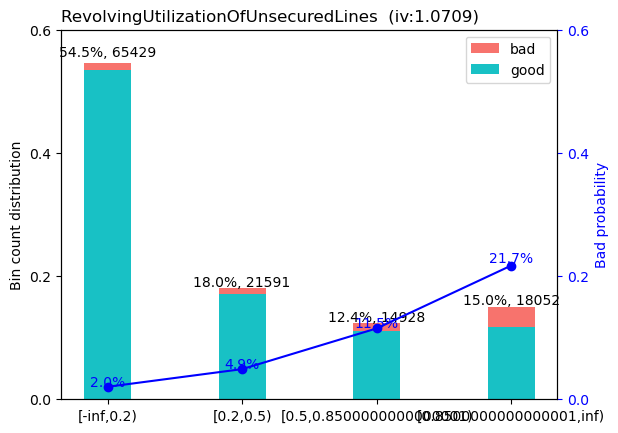

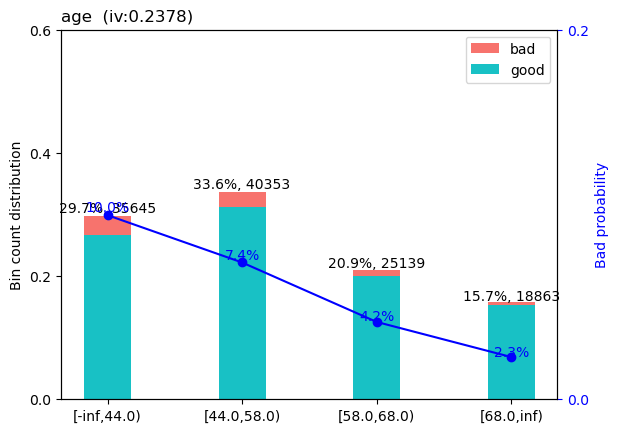

In [9]:
# ── Scorecard uses full df without imputation (missing = own bin) ──
df_sc = pd.read_csv(r'C:\Users\Srinivasa S Vemuri\Downloads\archive\cs-training.csv')
df_sc.drop(columns=['Unnamed: 0'], inplace=True)
df_sc = df_sc.rename(columns={'SeriousDlqin2yrs': 'y'})

train_sc, test_sc = train_test_split(df_sc, test_size=0.2, random_state=42, stratify=df_sc['y'])
print(f'Train: {train_sc.shape}  Test: {test_sc.shape}')

# ── WoE Binning ───────────────────────────────────────────────────
bins = sc.woebin(train_sc, y='y')
sc.woebin_plot(bins)
plt.show()

In [23]:
# ── Corrected IV table — computed from actual woebin() bins, not sc.iv() ──
# sc.iv() groups by every unique raw value of x, which massively inflates IV
# for continuous variables (see: scorecardpy.info_value.iv_xy source, which
# does .groupby('x') on unbinned values). The bins dict from sc.woebin()
# already has the correct, coarse, chi-merge-optimized bins — just sum bin_iv.

corrected_iv = pd.DataFrame({
    'variable': list(bins.keys()),
    'info_value_corrected': [bins[v]['bin_iv'].sum() for v in bins.keys()]
}).sort_values('info_value_corrected', ascending=False).reset_index(drop=True)

# Merge alongside the original (inflated) sc.iv() numbers for direct comparison
comparison = corrected_iv.merge(
    iv_summary.rename(columns={'info_value': 'info_value_raw_sc_iv'}),
    on='variable'
)
comparison['inflation_ratio'] = (comparison['info_value_raw_sc_iv'] /
                                   comparison['info_value_corrected']).round(1)

print(comparison.to_string(index=False))

                            variable  info_value_corrected  info_value_raw_sc_iv  inflation_ratio
RevolvingUtilizationOfUnsecuredLines              1.070942              0.308348              0.3
             NumberOfTimes90DaysLate              0.844395              0.888688              1.1
NumberOfTime30-59DaysPastDueNotWorse              0.728671              0.748536              1.0
NumberOfTime60-89DaysPastDueNotWorse              0.576722              0.605309              1.0
                                 age              0.237772              0.261985              1.1
     NumberOfOpenCreditLinesAndLoans              0.078317              0.121272              1.5
                           DebtRatio              0.071897              0.370686              5.2
                       MonthlyIncome              0.070809              0.913742             12.9
        NumberRealEstateLoansOrLines              0.058080              0.070504              1.2
                  Nu

In [21]:
# --- Cross-tab: default rate by value of NumberOfTimes90DaysLate ---
crosstab = pd.crosstab(X['NumberOfTimes90DaysLate'], y, normalize='index')
counts = X['NumberOfTimes90DaysLate'].value_counts().sort_index()

summary = pd.DataFrame({
    'Count': counts,
    'Default Rate': crosstab[1]  # assuming y=1 is default/delinquent
}).sort_index()

print(summary)

                          Count  Default Rate
NumberOfTimes90DaysLate                      
0                        141662      0.046265
1                          5243      0.336639
2                          1555      0.499035
3                           667      0.577211
4                           291      0.670103
5                           131      0.633588
6                            80      0.600000
7                            38      0.815789
8                            21      0.714286
9                            19      0.736842
10                            8      0.625000
11                            5      0.600000
12                            2      0.500000
13                            4      0.500000
14                            2      0.500000
15                            2      0.000000
17                            1      1.000000
96                            5      0.800000
98                          264      0.541667


In [22]:
# --- IV of MonthlyIncome computed only on non-missing rows ---
non_missing_mask = X['MonthlyIncome'].notna()

X_nonmiss = X.loc[non_missing_mask, ['MonthlyIncome']].copy()
y_nonmiss = y.loc[non_missing_mask]

bins_nonmiss = sc.woebin(
    pd.concat([X_nonmiss, y_nonmiss.rename('target')], axis=1),
    y='target'
)

iv_nonmiss_only = bins_nonmiss['MonthlyIncome']['bin_iv'].sum()
print(f"IV of MonthlyIncome, non-missing rows only: {iv_nonmiss_only:.4f}")

[INFO] creating woe binning ...
Binning on 150000 rows and 2 columns in 00:00:13
IV of MonthlyIncome, non-missing rows only: 0.0691


[INFO] converting into woe values ...
[INFO] converting into woe values ...


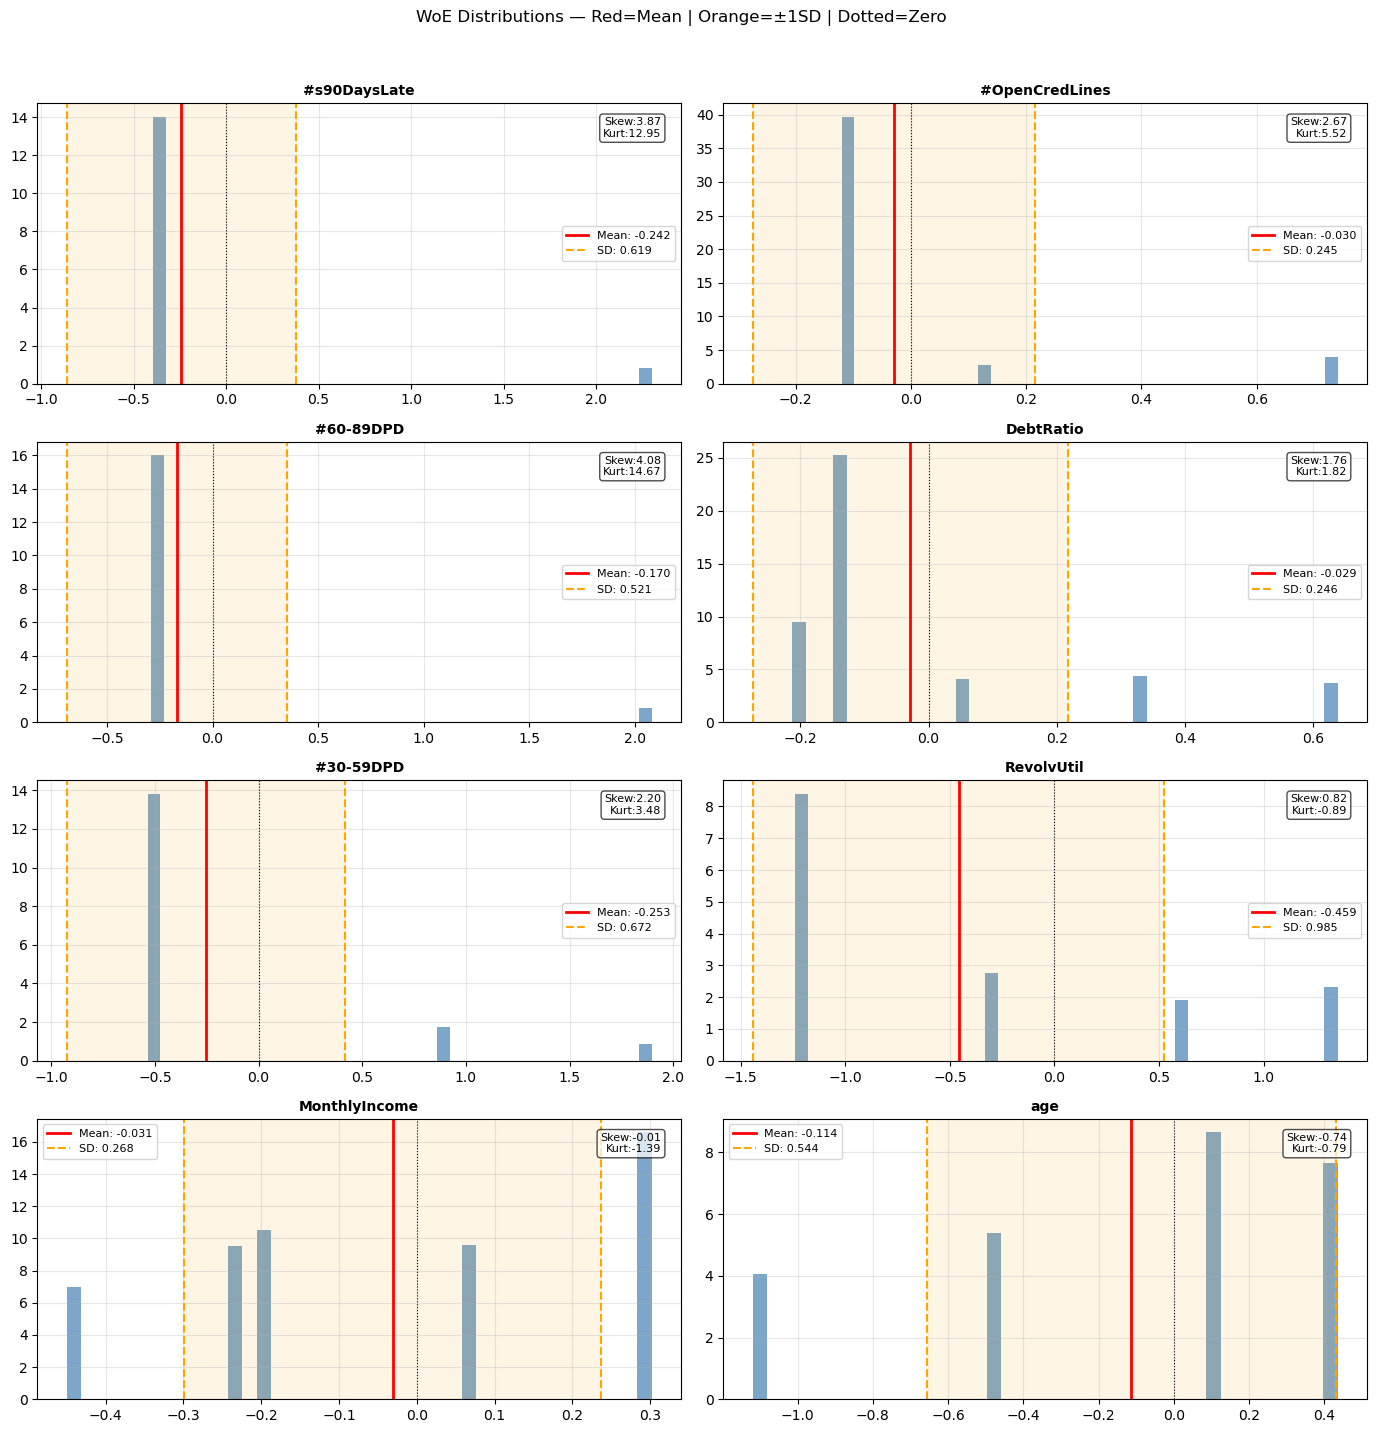

In [18]:
# ── WoE Transformation ────────────────────────────────────────────
selected_vars = [
    'MonthlyIncome', 'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines',
    'age', 'NumberOfOpenCreditLinesAndLoans'
]
bins_selected = {v: bins[v] for v in selected_vars}

train_woe = sc.woebin_ply(train_sc, bins_selected)
test_woe  = sc.woebin_ply(test_sc,  bins_selected)

woe_cols   = [c for c in train_woe.columns
              if c.endswith('_woe') and c not in
              ['NumberRealEstateLoansOrLines_woe','NumberOfDependents_woe']]

X_train_woe = train_woe[woe_cols];  y_train_woe = train_woe['y']
X_test_woe  = test_woe[woe_cols];   y_test_woe  = test_woe['y']

# ── WoE distribution plots ────────────────────────────────────────
labels = {c: c.replace('_woe','').replace('RevolvingUtilizationOfUnsecuredLines','RevolvUtil')
                .replace('NumberOfTime','#').replace('DaysPastDueNotWorse','DPD')
                .replace('NumberOfTimes90DaysLate','#90DaysLate')
                .replace('NumberOfOpenCreditLinesAndLoans','#OpenCredLines')
          for c in woe_cols}

nrows = (len(woe_cols)+1)//2
fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows*3.5))
axes = axes.flatten()

for i, col in enumerate(woe_cols):
    data = train_woe[col].dropna()
    mu, sd = data.mean(), data.std()
    axes[i].hist(data, bins=40, density=True, color='steelblue', alpha=0.7)
    axes[i].axvline(mu,    color='red',    lw=2, ls='-',  label=f'Mean: {mu:.3f}')
    axes[i].axvline(mu+sd, color='orange', lw=1.5, ls='--', label=f'SD: {sd:.3f}')
    axes[i].axvline(mu-sd, color='orange', lw=1.5, ls='--')
    axes[i].axvline(0,     color='black',  lw=0.8, ls=':')
    axes[i].axvspan(mu-sd, mu+sd, alpha=0.1, color='orange')
    axes[i].set_title(labels[col], fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8); axes[i].grid(True, alpha=0.3)
    skew = data.skew(); kurt = data.kurtosis()
    axes[i].text(0.97, 0.95, f'Skew:{skew:.2f}\nKurt:{kurt:.2f}',
                 transform=axes[i].transAxes, fontsize=8, va='top', ha='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

for j in range(len(woe_cols), len(axes)): axes[j].set_visible(False)
plt.suptitle('WoE Distributions — Red=Mean | Orange=±1SD | Dotted=Zero', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

WoE LR | Train: 0.8544 | Test: 0.8577 | Gini: 0.7154
Optimization terminated successfully.
         Current function value: 0.184150
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               120000
Model:                          Logit   Df Residuals:                   119991
Method:                           MLE   Df Model:                            8
Date:                Tue, 11 Aug 2026   Pseudo R-squ.:                  0.2496
Time:                        23:24:11   Log-Likelihood:                -22098.
converged:                       True   LL-Null:                       -29447.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

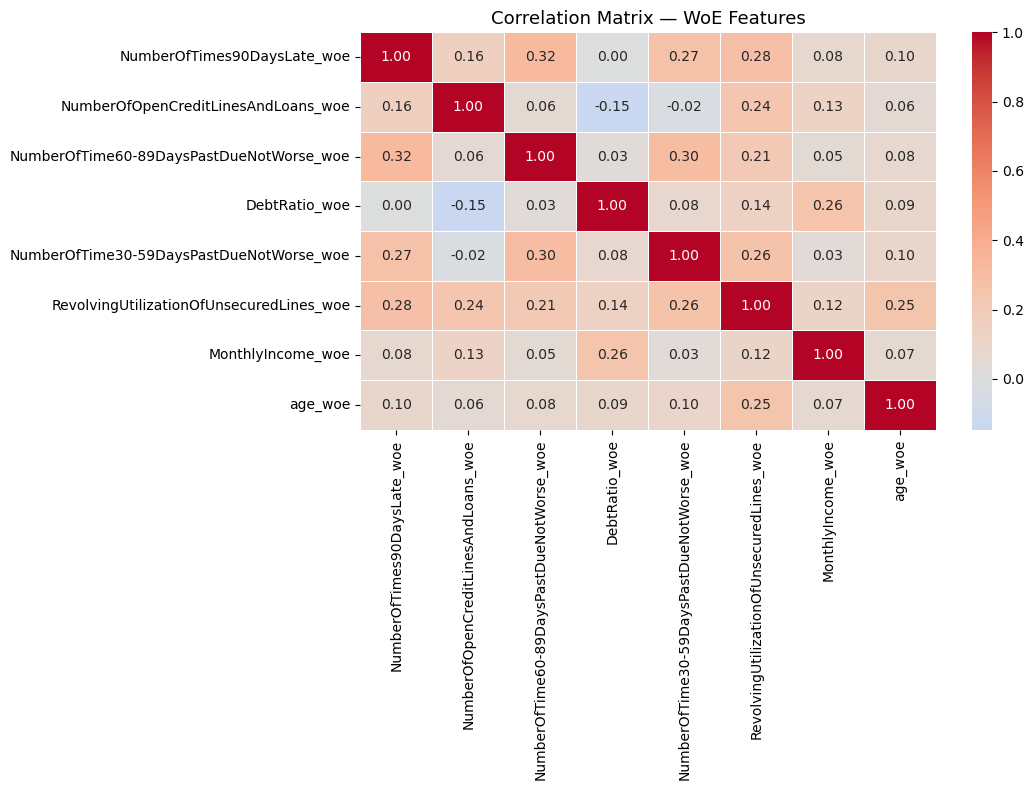

In [19]:
# ── Logistic Regression on WoE features ──────────────────────────
lr_woe = LogisticRegression(max_iter=1000)
lr_woe.fit(X_train_woe, y_train_woe)

auc_woe_train = roc_auc_score(y_train_woe, lr_woe.predict_proba(X_train_woe)[:,1])
auc_woe_test  = roc_auc_score(y_test_woe,  lr_woe.predict_proba(X_test_woe)[:,1])
gini_woe      = 2 * auc_woe_test - 1
print(f'WoE LR | Train: {auc_woe_train:.4f} | Test: {auc_woe_test:.4f} | Gini: {gini_woe:.4f}')

# ── Statsmodels for coefficient p-values ─────────────────────────
result = sm.Logit(y_train_woe, sm.add_constant(X_train_woe)).fit()
print(result.summary())

# ── Coefficient check: all should be positive ─────────────────────
coef_df = pd.DataFrame({'Feature': woe_cols, 'Coefficient': lr_woe.coef_[0]})\
            .sort_values('Coefficient', ascending=False)
print('\nCoefficient check (all should be positive):')
print(coef_df.to_string(index=False))

# ── WoE correlation matrix ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(X_train_woe.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — WoE Features', fontsize=13)
plt.tight_layout(); plt.show()

In [16]:
# ── Build Scorecard ───────────────────────────────────────────────
card = sc.scorecard(bins_selected, lr_woe, woe_cols, points0=600, odds0=1/50, pdo=20)

for var, table in card.items():
    print(f"\n{'='*45}\nVariable: {var}")
    print(table[['bin','points']])

# ── Score computation ─────────────────────────────────────────────
train_score = sc.scorecard_ply(train_sc, card, only_total_score=True)
test_score  = sc.scorecard_ply(test_sc,  card, only_total_score=True)
test_score['y'] = test_sc['y'].values

defaulters     = test_score[test_score['y']==1]['score']
non_defaulters = test_score[test_score['y']==0]['score']

print(f'Score range: {test_score["score"].min():.0f} to {test_score["score"].max():.0f}')
print(f'Mean — Non-defaulters: {non_defaulters.mean():.1f}  Defaulters: {defaulters.mean():.1f}')


Variable: basepoints
   bin  points
0  NaN   562.0

Variable: age
            bin  points
21  [-inf,44.0)    -6.0
22  [44.0,58.0)    -1.0
23  [58.0,68.0)     7.0
24   [68.0,inf)    15.0

Variable: NumberOfTime60-89DaysPastDueNotWorse
           bin  points
10  [-inf,1.0)     3.0
11   [1.0,inf)   -25.0

Variable: NumberOfOpenCreditLinesAndLoans
           bin  points
25  [-inf,3.0)    -2.0
26   [3.0,4.0)    -0.0
27   [4.0,inf)     0.0

Variable: RevolvingUtilizationOfUnsecuredLines
                         bin  points
17                [-inf,0.2)    22.0
18                 [0.2,0.5)     6.0
19  [0.5,0.8500000000000001)   -11.0
20  [0.8500000000000001,inf)   -24.0

Variable: NumberOfTimes90DaysLate
          bin  points
5  [-inf,1.0)     6.0
6   [1.0,inf)   -36.0

Variable: DebtRatio
                          bin  points
12                 [-inf,0.4)     3.0
13                  [0.4,0.5)    -1.0
14   [0.5,0.7000000000000001)    -7.0
15  [0.7000000000000001,2.95)   -14.0
16              

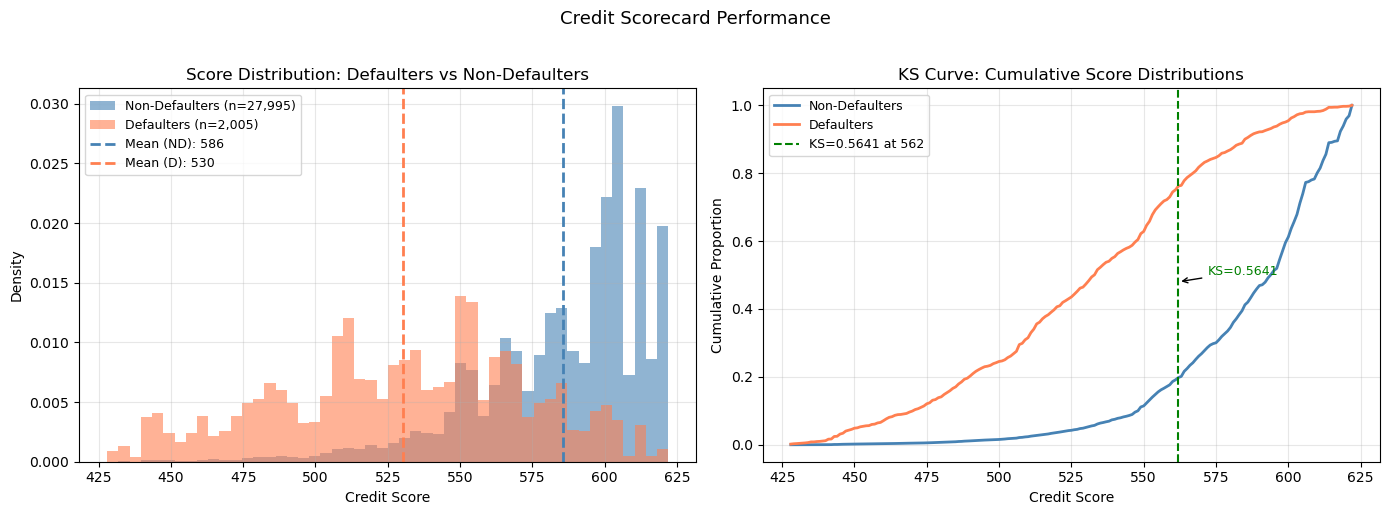

KS=0.5641  Gini=0.7154  AUC=0.8577


In [17]:
# ── Score distribution + KS curve ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(non_defaulters, bins=50, alpha=0.6, color='steelblue',
             density=True, label=f'Non-Defaulters (n={len(non_defaulters):,})')
axes[0].hist(defaulters,     bins=50, alpha=0.6, color='coral',
             density=True, label=f'Defaulters (n={len(defaulters):,})')
axes[0].axvline(non_defaulters.mean(), color='steelblue', lw=2, ls='--',
                label=f'Mean (ND): {non_defaulters.mean():.0f}')
axes[0].axvline(defaulters.mean(),     color='coral',     lw=2, ls='--',
                label=f'Mean (D): {defaulters.mean():.0f}')
axes[0].set_xlabel('Credit Score'); axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution: Defaulters vs Non-Defaulters')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

scores_sorted  = np.sort(test_score['score'].unique())
cum_d   = [(defaulters     <= s).mean() for s in scores_sorted]
cum_nd  = [(non_defaulters <= s).mean() for s in scores_sorted]
ks_diff = np.abs(np.array(cum_d) - np.array(cum_nd))
ks_idx  = np.argmax(ks_diff)
ks_stat = ks_diff[ks_idx]
ks_score= scores_sorted[ks_idx]

axes[1].plot(scores_sorted, cum_nd, color='steelblue', lw=2, label='Non-Defaulters')
axes[1].plot(scores_sorted, cum_d,  color='coral',     lw=2, label='Defaulters')
axes[1].axvline(ks_score, color='green', ls='--', lw=1.5,
                label=f'KS={ks_stat:.4f} at {ks_score:.0f}')
axes[1].annotate(f'KS={ks_stat:.4f}',
                 xy=(ks_score,(cum_d[ks_idx]+cum_nd[ks_idx])/2),
                 xytext=(ks_score+10,0.5), fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->'))
axes[1].set_xlabel('Credit Score'); axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('KS Curve: Cumulative Score Distributions')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Credit Scorecard Performance', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f'KS={ks_stat:.4f}  Gini={gini_woe:.4f}  AUC={auc_woe_test:.4f}')

In [18]:
# ── PSI: train vs test score distribution ─────────────────────────
train_score_vals = sc.scorecard_ply(train_sc, card, only_total_score=True)['score']
test_score_vals  = test_score['score']

def get_decile_pcts(scores, cuts):
    counts = pd.cut(scores, bins=cuts).value_counts().sort_index()
    return counts / counts.sum()

decile_cuts       = np.percentile(train_score_vals, np.arange(0,110,10))
decile_cuts[0]    = -np.inf
decile_cuts[-1]   = np.inf

pct_train = get_decile_pcts(train_score_vals, decile_cuts)
pct_test  = get_decile_pcts(test_score_vals,  decile_cuts)

psi_df = pd.DataFrame({
    'Decile':      range(1,11),
    'Score Range': [str(x) for x in pct_train.index],
    'Train % (B)': pct_train.values,
    'Test % (A)':  pct_test.values
})
psi_df['A-B']     = psi_df['Test % (A)']  - psi_df['Train % (B)']
psi_df['ln(A/B)'] = np.log(psi_df['Test % (A)'] / psi_df['Train % (B)'])
psi_df['PSI term']= psi_df['A-B'] * psi_df['ln(A/B)']

total_psi = psi_df['PSI term'].sum()
print(psi_df.round(6).to_string(index=False))
print(f'\nTotal PSI: {total_psi:.6f}')
verdict = 'STABLE' if total_psi<0.1 else 'MONITOR' if total_psi<0.25 else 'REBUILD'
print(f'Verdict: {verdict}')

 Decile    Score Range  Train % (B)  Test % (A)       A-B   ln(A/B)  PSI term
      1  (-inf, 537.0]     0.100667    0.099067 -0.001600 -0.016022  0.000026
      2 (537.0, 557.0]     0.103250    0.104300  0.001050  0.010118  0.000011
      3 (557.0, 570.0]     0.100108    0.102200  0.002092  0.020679  0.000043
      4 (570.0, 582.0]     0.098675    0.099600  0.000925  0.009331  0.000009
      5 (582.0, 592.0]     0.102925    0.103667  0.000742  0.007180  0.000005
      6 (592.0, 599.0]     0.111833    0.110267 -0.001567 -0.014108  0.000022
      7 (599.0, 604.0]     0.112333    0.110067 -0.002267 -0.020384  0.000046
      8 (604.0, 610.0]     0.082033    0.083867  0.001833  0.022103  0.000041
      9 (610.0, 616.0]     0.088633    0.087700 -0.000933 -0.010586  0.000010
     10   (616.0, inf]     0.099542    0.099267 -0.000275 -0.002766  0.000001

Total PSI: 0.000213
Verdict: STABLE


## 8. Model Comparison and Feature Importance

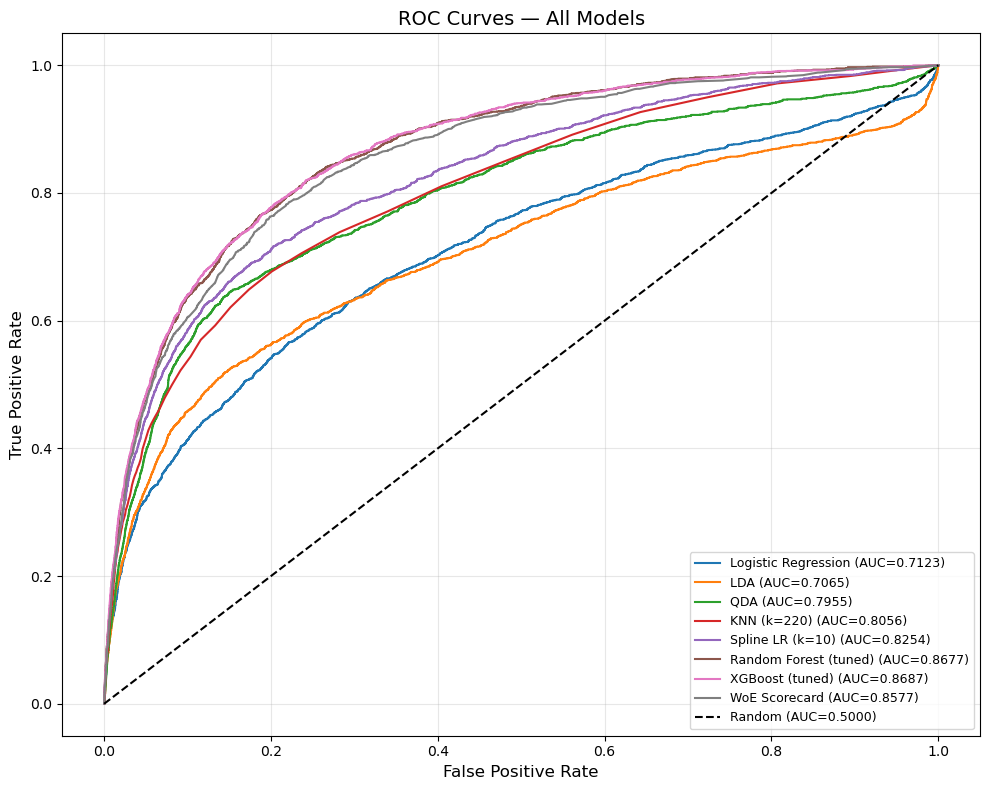

In [19]:
# ── ROC curves — all models ────────────────────────────────────────
all_models = {
    'Logistic Regression':   (lr,         X_test_raw,  y_test_raw),
    'LDA':                   (lda,        X_test_raw,  y_test_raw),
    'QDA':                   (qda,        X_test_raw,  y_test_raw),
    f'KNN (k={best_k})':     (knn_best,   X_test_raw,  y_test_raw),
    f'Spline LR (k={ose_knots})': (spline_pipe, X_test_raw, y_test_raw),
    'Random Forest (tuned)': (rf_best,    X_test_raw,  y_test_raw),
    'XGBoost (tuned)':       (xgb_final,  X_test_raw,  y_test_raw),
    'WoE Scorecard':         (lr_woe,     X_test_woe,  y_test_woe),
}

plt.figure(figsize=(10, 8))
for name, (model, Xt, yt) in all_models.items():
    fpr, tpr, _ = roc_curve(yt, model.predict_proba(Xt)[:,1])
    auc = roc_auc_score(yt, model.predict_proba(Xt)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.5000)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=9); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

                 Model  Brier Score
0        WoE Scorecard       0.0504
1     Spline LR (k=10)       0.0517
2          KNN (k=220)       0.0537
3                  LDA       0.0571
4  Logistic Regression       0.0573
5                  QDA       0.0738
6        Random Forest       0.1265
7              XGBoost       0.1430


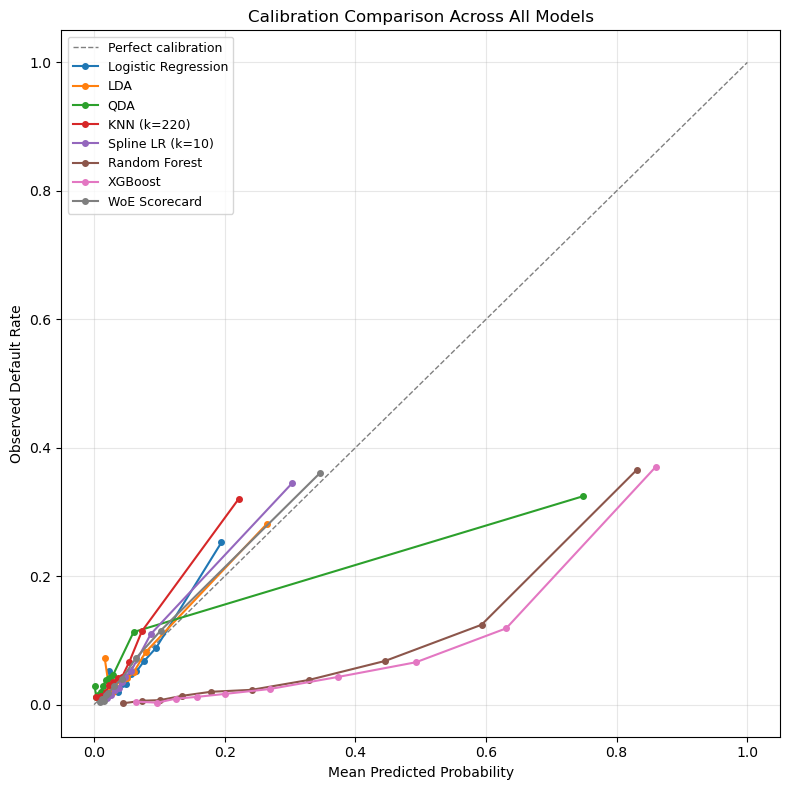

In [20]:
models_probs = {
    'Logistic Regression': lr.predict_proba(X_test_raw)[:,1],
    'LDA':                 lda.predict_proba(X_test_raw)[:,1],
    'QDA':                 qda.predict_proba(X_test_raw)[:,1],
    'KNN (k=220)':         knn_best.predict_proba(X_test_raw)[:,1],
    'Spline LR (k=10)':    spline_pipe.predict_proba(X_test_raw)[:, 1],
    'Random Forest':       rf_best.predict_proba(X_test_raw)[:, 1],
    'XGBoost':             xgb_final.predict_proba(X_test_raw)[:, 1],
    'WoE Scorecard':       lr_woe.predict_proba(X_test_woe)[:,1],
}

y_true = y_test_raw  # true binary labels, same length/order as each probability array above

# --- Compute calibration curve + Brier score for each model ---
results = {}
brier_scores = []

for name, y_prob in models_probs.items():
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_true, y_prob)
    results[name] = (prob_pred, prob_true)
    brier_scores.append({'Model': name, 'Brier Score': round(brier, 4)})

# --- Brier score summary table (lower = better calibrated) ---
brier_df = pd.DataFrame(brier_scores).sort_values('Brier Score').reset_index(drop=True)
print(brier_df)

# --- Overlay plot ---
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect calibration')

colors = plt.cm.tab10.colors
for i, (name, (prob_pred, prob_true)) in enumerate(results.items()):
    plt.plot(prob_pred, prob_true, marker='o', markersize=4,
              color=colors[i % len(colors)], label=name)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Rate')
plt.title('Calibration Comparison Across All Models')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ── AUC summary table ─────────────────────────────────────────────
summary = []
train_preds = {
    'Logistic Regression':        (lr,         X_train_raw,  y_train_raw),
    'LDA':                        (lda,        X_train_raw,  y_train_raw),
    'QDA':                        (qda,        X_train_raw,  y_train_raw),
    f'KNN (k={best_k})':          (knn_best,   X_train_raw,  y_train_raw),
    f'Spline LR (k={ose_knots})': (spline_pipe,X_train_raw,  y_train_raw),
    'Random Forest (tuned)':      (rf_best,    X_trainval,   y_trainval),
    'XGBoost (tuned)':            (xgb_final,  X_trainval,   y_trainval),
    'WoE Scorecard':              (lr_woe,     X_train_woe,  y_train_woe),
}

for name, (model, Xtr, ytr) in train_preds.items():
    Xt, yt = all_models[name][1], all_models[name][2]
    tr_auc = roc_auc_score(ytr, model.predict_proba(Xtr)[:,1])
    te_auc = roc_auc_score(yt,  model.predict_proba(Xt)[:,1])
    summary.append({'Model': name, 'Train AUC': tr_auc,
                    'Test AUC': te_auc, 'Gini': 2*te_auc-1,
                    'Gap': tr_auc-te_auc})

summary_df = pd.DataFrame(summary).sort_values('Test AUC', ascending=False)
print('='*75)
print('MODEL COMPARISON — sorted by Test AUC')
print('='*75)
print(summary_df.round(4).to_string(index=False))

MODEL COMPARISON — sorted by Test AUC
                Model  Train AUC  Test AUC   Gini     Gap
      XGBoost (tuned)     0.8689    0.8687 0.7374  0.0002
Random Forest (tuned)     0.9014    0.8677 0.7354  0.0337
        WoE Scorecard     0.8544    0.8577 0.7154 -0.0033
     Spline LR (k=10)     0.8179    0.8254 0.6508 -0.0075
          KNN (k=220)     0.8204    0.8056 0.6112  0.0148
                  QDA     0.7911    0.7955 0.5909 -0.0044
  Logistic Regression     0.6905    0.7123 0.4246 -0.0218
                  LDA     0.6870    0.7065 0.4129 -0.0194


Computing permutation importance...


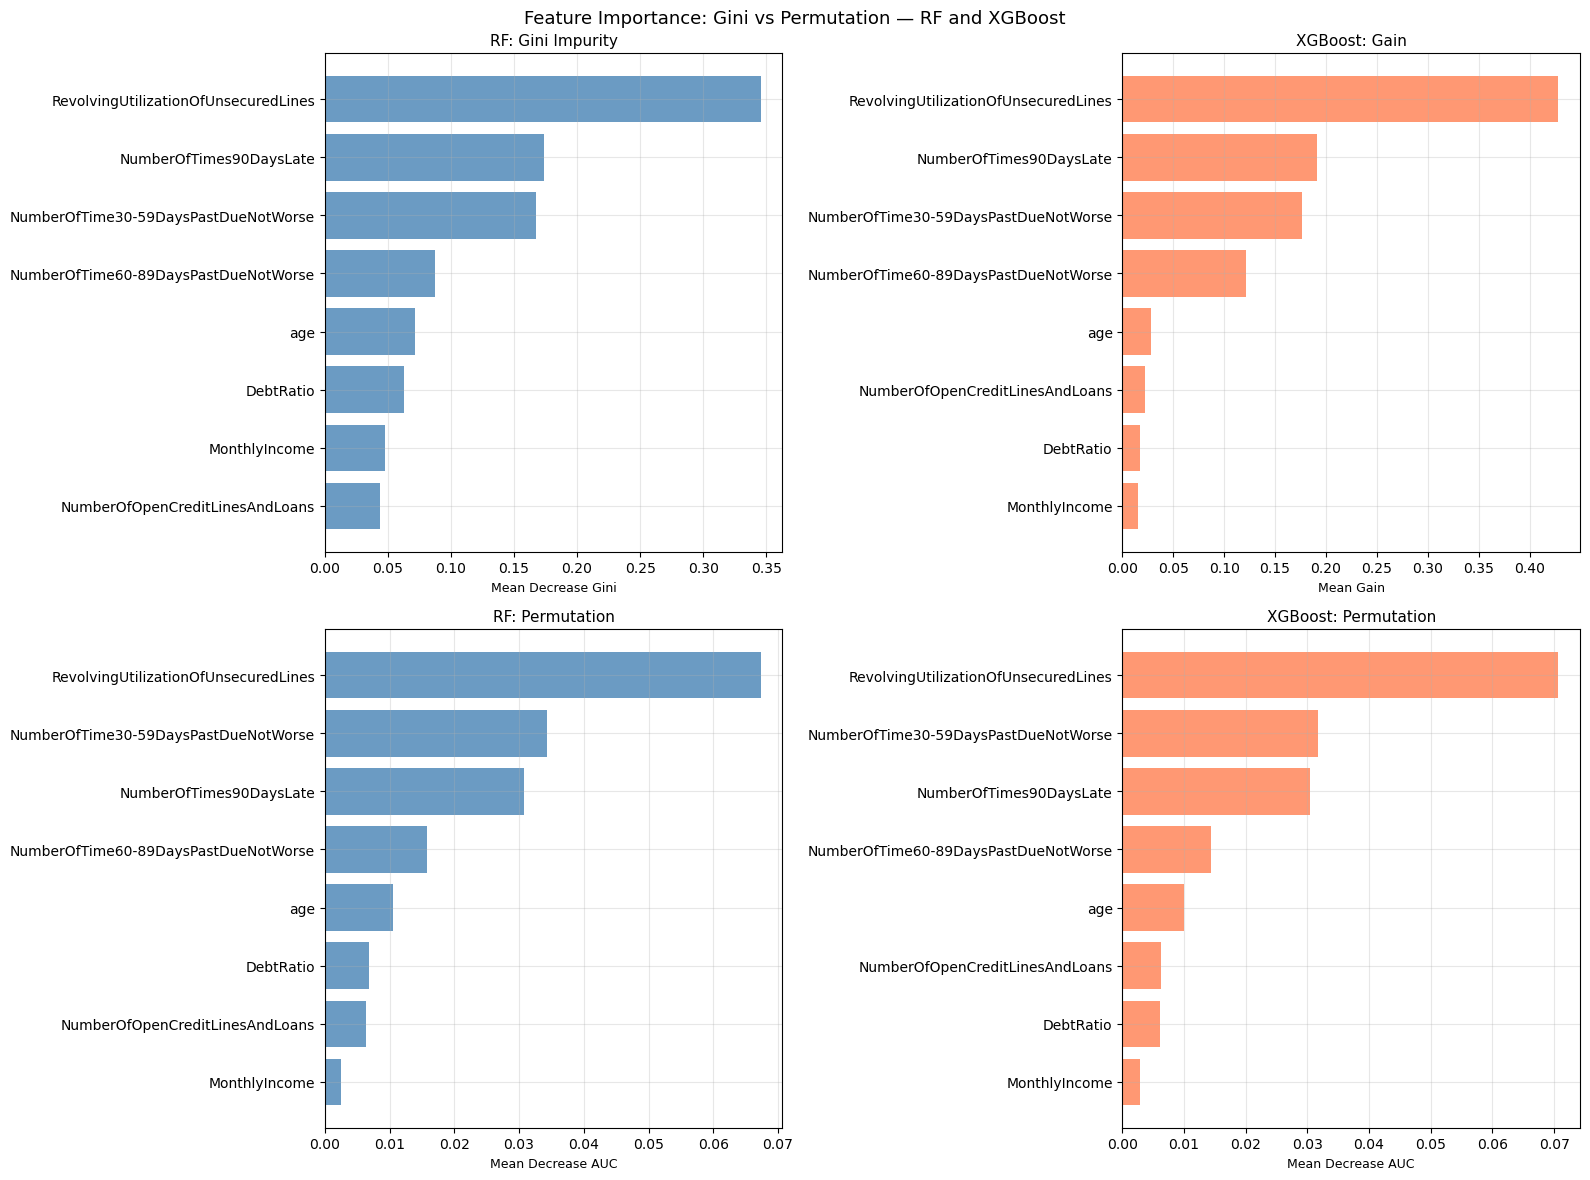

In [21]:
# ── Feature importance: Gini + Permutation (RF and XGBoost) ──────
rf_gini  = rf_best.feature_importances_
xgb_gain = xgb_final.feature_importances_

print('Computing permutation importance...')
perm_rf  = permutation_importance(rf_best,  X_test_raw, y_test_raw,
                                   n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1)
perm_xgb = permutation_importance(xgb_final,X_test_raw, y_test_raw,
                                   n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1)

# ── Importance plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, vals, title, xlabel, color in [
    (axes[0,0], rf_gini,                 'RF: Gini Impurity',    'Mean Decrease Gini',  'steelblue'),
    (axes[0,1], xgb_gain,                'XGBoost: Gain',        'Mean Gain',            'coral'),
    (axes[1,0], perm_rf.importances_mean, 'RF: Permutation',     'Mean Decrease AUC',   'steelblue'),
    (axes[1,1], perm_xgb.importances_mean,'XGBoost: Permutation','Mean Decrease AUC',   'coral'),
]:
    idx = vals.argsort()
    ax.barh([raw_cols[i] for i in idx], vals[idx], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11); ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Importance: Gini vs Permutation — RF and XGBoost', fontsize=13)
plt.tight_layout(); plt.show()

FEATURE IMPORTANCE — VALUES (sorted by IV)
                             Feature     IV  WoE_Beta  XGB_Perm  RF_Perm  RF_Gini  XGB_Gain
                       MonthlyIncome 0.9137    0.1350    0.0029   0.0024   0.0479    0.0155
             NumberOfTimes90DaysLate 0.8887    0.5444    0.0305   0.0307   0.1737    0.1908
NumberOfTime30-59DaysPastDueNotWorse 0.7485    0.5162    0.0317   0.0344   0.1675    0.1761
NumberOfTime60-89DaysPastDueNotWorse 0.6053    0.4099    0.0144   0.0158   0.0877    0.1218
                           DebtRatio 0.3707    0.7561    0.0061   0.0068   0.0625    0.0168
RevolvingUtilizationOfUnsecuredLines 0.3083    0.6245    0.0707   0.0673   0.3455    0.4280
                                 age 0.2620    0.4597    0.0100   0.0105   0.0717    0.0284
     NumberOfOpenCreditLinesAndLoans 0.1213    0.0879    0.0063   0.0063   0.0436    0.0226

FEATURE IMPORTANCE — RANKS (1 = most important)
                             Feature  IV_Rank  WoE_Beta_Rank  XGB_Perm_Rank  RF_

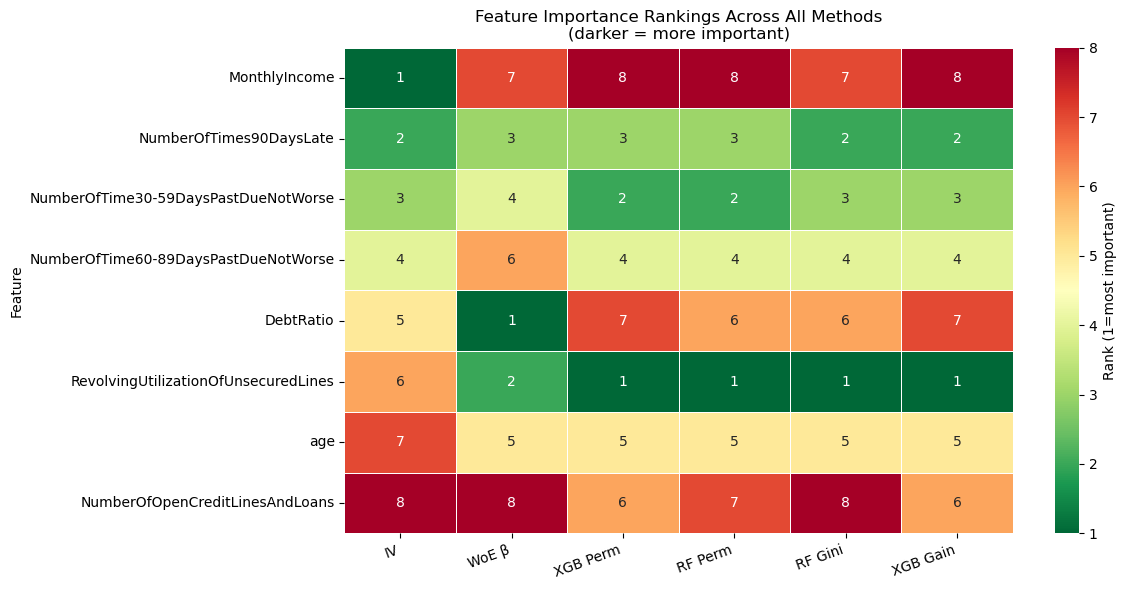

In [23]:
# ── Combined importance table: IV | WoE β | RF Perm | XGB Perm ───
iv_df    = iv_summary[iv_summary['variable'].isin(raw_cols)][['variable','info_value']]\
             .set_index('variable').rename(columns={'info_value':'IV'})
woe_df   = pd.DataFrame({'Feature':[c.replace('_woe','') for c in woe_cols],
                          'WoE_Beta':lr_woe.coef_[0]}).set_index('Feature')
xperm_df = pd.DataFrame({'Feature':raw_cols,'XGB_Perm':perm_xgb.importances_mean}).set_index('Feature')
rperm_df = pd.DataFrame({'Feature':raw_cols,'RF_Perm': perm_rf.importances_mean}).set_index('Feature')
rgini_df = pd.DataFrame({'Feature':raw_cols,'RF_Gini': rf_gini}).set_index('Feature')
xgain_df = pd.DataFrame({'Feature':raw_cols,'XGB_Gain':xgb_gain}).set_index('Feature')

combined = iv_df.join(woe_df).join(xperm_df).join(rperm_df).join(rgini_df).join(xgain_df)
combined = combined.reset_index().rename(columns={'variable': 'Feature'})  # ← fix here
combined = combined.sort_values('IV', ascending=False).reset_index(drop=True)

for col in ['IV','WoE_Beta','XGB_Perm','RF_Perm','RF_Gini','XGB_Gain']:
    combined[f'{col}_Rank'] = combined[col].rank(ascending=False).astype(int)

print('FEATURE IMPORTANCE — VALUES (sorted by IV)')
print(combined[['Feature','IV','WoE_Beta','XGB_Perm','RF_Perm','RF_Gini','XGB_Gain']]
      .round(4).to_string(index=False))

print('\nFEATURE IMPORTANCE — RANKS (1 = most important)')
print(combined[['Feature','IV_Rank','WoE_Beta_Rank','XGB_Perm_Rank',
                'RF_Perm_Rank','RF_Gini_Rank','XGB_Gain_Rank']].to_string(index=False))

# ── Rank heatmap ──────────────────────────────────────────────────
rank_mat = combined.set_index('Feature')[['IV_Rank','WoE_Beta_Rank','XGB_Perm_Rank',
                                           'RF_Perm_Rank','RF_Gini_Rank','XGB_Gain_Rank']]
rank_mat.columns = ['IV','WoE β','XGB Perm','RF Perm','RF Gini','XGB Gain']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(rank_mat, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Rank (1=most important)'})
ax.set_title('Feature Importance Rankings Across All Methods\n(darker = more important)',
             fontsize=12)
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()